# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

df = pd.read_csv('data.csv')
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

--- Age Summary Statistics ---
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

--------------------------------------------------



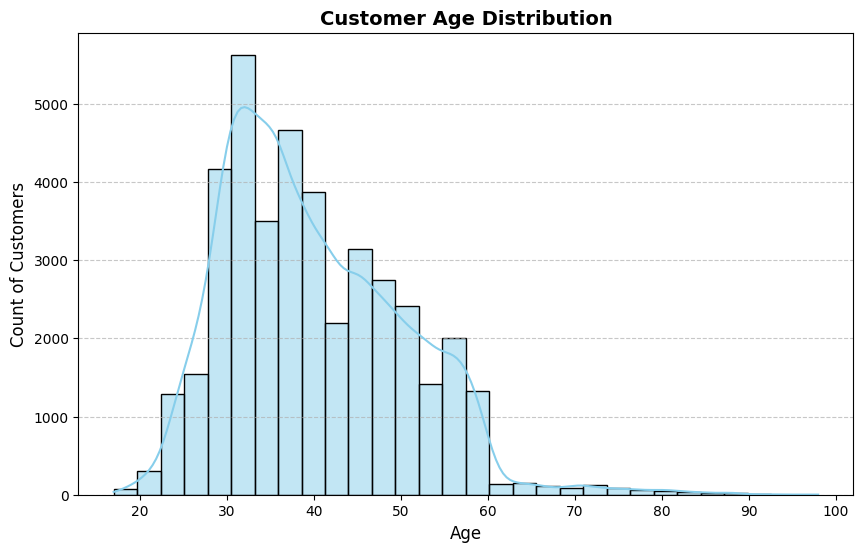

In [6]:
# Age distribution
# 1. Load your bank data
df = pd.read_csv('data.csv')

# 2. Check basic age statistics (Mean, Min, Max, etc.)
print("--- Age Summary Statistics ---")
print(df['age'].describe())
print("\n--------------------------------------------------\n")

# 3. Create the age distribution chart
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=30, color='skyblue')

plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Display the chart
plt.show()

--- Job Counts ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--------------------------------------------------



/tmp/ipykernel_541/1365431358.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='job', order=df['job'].value_counts().index, palette='viridis')


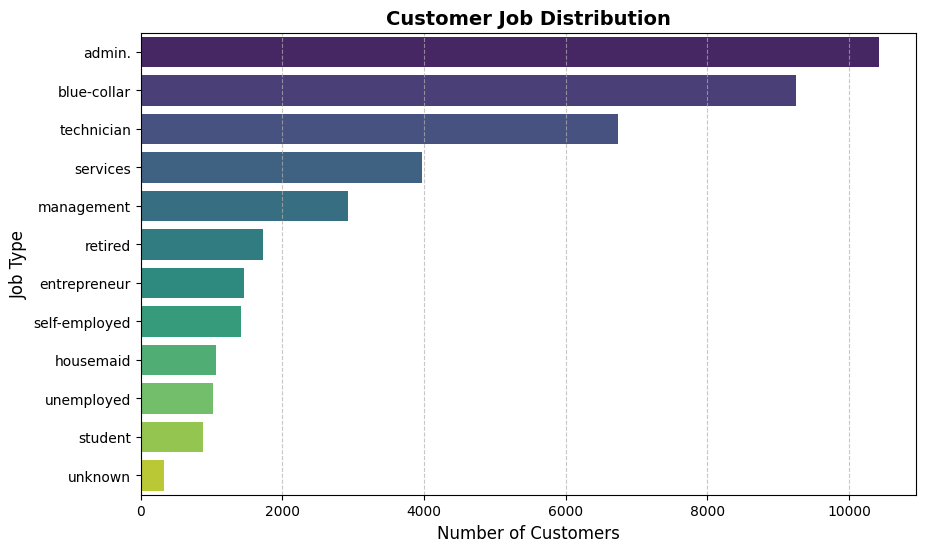

In [7]:
# Job distribution
# 1. Count how many customers are in each job category
print("--- Job Counts ---")
print(df['job'].value_counts())
print("\n--------------------------------------------------\n")

# 2. Create a clean, horizontal bar chart
plt.figure(figsize=(10, 6))

# sns.countplot makes a bar for each unique text category automatically
# Setting y='job' makes the bars horizontal and easy to read
sns.countplot(data=df, y='job', order=df['job'].value_counts().index, palette='viridis')

plt.title('Customer Job Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Job Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 3. Display the chart
plt.show()


## Balance & Deposit Trends

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
--- Average Call Duration by Subscription Status ---
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

--------------------------------------------------



/tmp/ipykernel_541/4183301864.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_duration.index, y=avg_duration.values, palette='Set2')


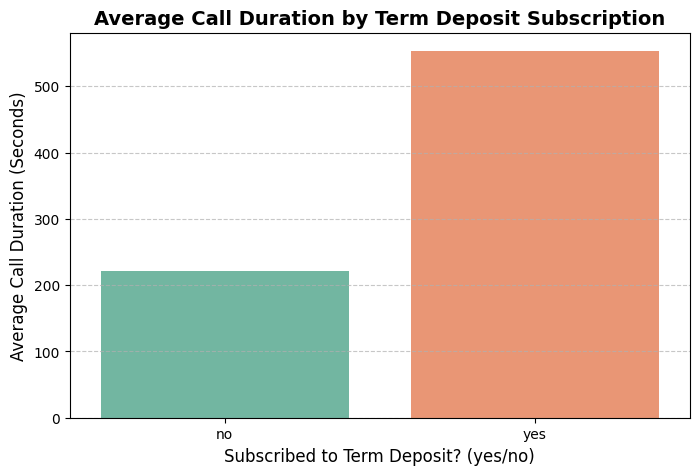

In [10]:
# Print out all column names in your data
print(df.columns.tolist())
# 1. Calculate the exact average call duration (in seconds) for 'yes' vs 'no'
print("--- Average Call Duration by Subscription Status ---")
avg_duration = df.groupby('y')['duration'].mean()
print(avg_duration)
print("\n--------------------------------------------------\n")

# 2. Create a bar chart to visually compare them
plt.figure(figsize=(8, 5))

sns.barplot(x=avg_duration.index, y=avg_duration.values, palette='Set2')

plt.title('Average Call Duration by Term Deposit Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (yes/no)', fontsize=12)
plt.ylabel('Average Call Duration (Seconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Display the chart
plt.show()

## Campaign Effectiveness

--- Subscription Success Rate (%) by Contact Method ---
y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321

--------------------------------------------------



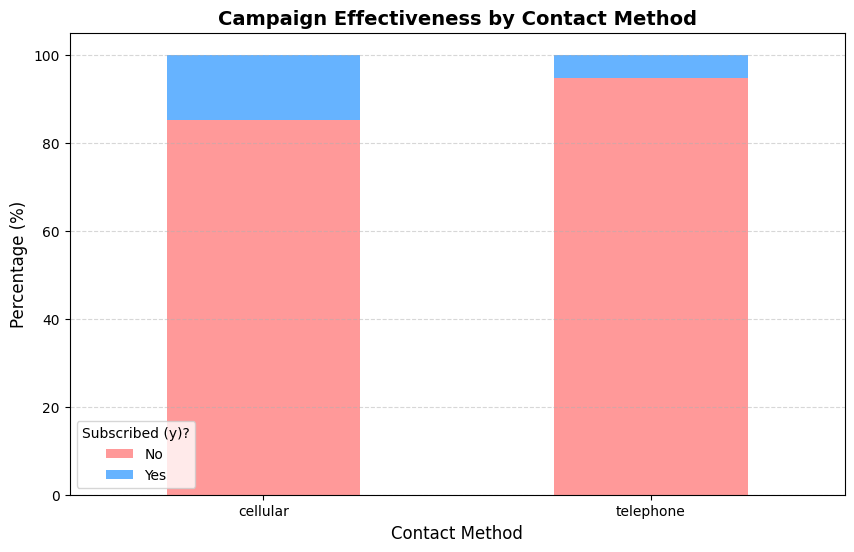

In [11]:
# Contact method analysis
# 1. Create a cross-tabulation of Contact Method vs Subscription Status
contact_y_table = pd.crosstab(df['contact'], df['y'])

# 2. Convert counts to percentages to see the true success rate
contact_pct = contact_y_table.div(contact_y_table.sum(1), axis=0) * 100

print("--- Subscription Success Rate (%) by Contact Method ---")
print(contact_pct)
print("\n--------------------------------------------------\n")

# 3. Plot the stacked bar chart
# 'stacked=True' stacks 'yes' on top of 'no' so it totals 100%
contact_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])

plt.title('Campaign Effectiveness by Contact Method', fontsize=14, fontweight='bold')
plt.xlabel('Contact Method', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)  # Keeps the words horizontal and easy to read
plt.legend(title='Subscribed (y)?', labels=['No', 'Yes'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Display the chart
plt.show()

--- Average Number of Contacts by Subscription Status ---
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64

--------------------------------------------------



/tmp/ipykernel_541/831725930.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='campaign', palette='Pastel1', showfliers=False)


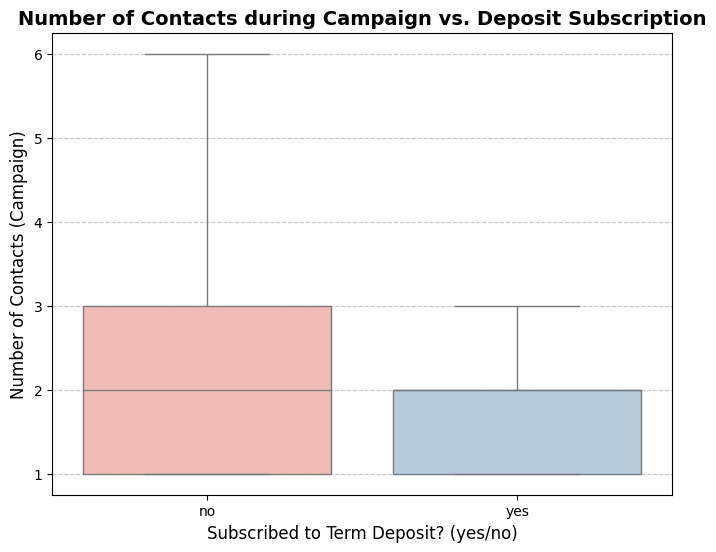

In [12]:
# Number of contacts vs deposit subscription
# 1. Calculate the average number of contacts for 'yes' vs 'no'
print("--- Average Number of Contacts by Subscription Status ---")
avg_contacts = df.groupby('y')['campaign'].mean()
print(avg_contacts)
print("\n--------------------------------------------------\n")

# 2. Create a box plot to see the distribution of contacts
plt.figure(figsize=(8, 6))

# showfliers=False hides extreme outliers so the boxes are easy to read
sns.boxplot(data=df, x='y', y='campaign', palette='Pastel1', showfliers=False)

plt.title('Number of Contacts during Campaign vs. Deposit Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (yes/no)', fontsize=12)
plt.ylabel('Number of Contacts (Campaign)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Display the chart
plt.show()


## Correlation Heatmap

In [ ]:
## 1. Calculate the average number of contacts for 'yes' vs 'no'
print("--- Average Number of Contacts by Subscription Status ---")
avg_contacts = df.groupby('y')['campaign'].mean()
print(avg_contacts)
print("\n--------------------------------------------------\n")

# 2. Create a box plot to see the distribution of contacts
plt.figure(figsize=(8, 6))

# showfliers=False hides extreme outliers so the boxes are easy to read
sns.boxplot(data=df, x='y', y='campaign', palette='Pastel1', showfliers=False)

plt.title('Number of Contacts during Campaign vs. Deposit Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (yes/no)', fontsize=12)
plt.ylabel('Number of Contacts (Campaign)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Display the chart
plt.show()

# Predictive Modeling (Logistic Regression)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Model Accuracy Score ---
Accuracy: 90.48%

--------------------------------------------------

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7303
           1       0.66      0.33      0.44       935

    accuracy                           0.90      8238
   macro avg       0.79      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238


--------------------------------------------------



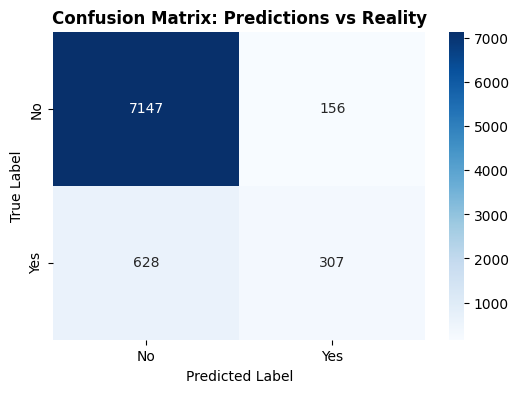

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Prepare Data: Select features (X) and target variable (y)
# We will use numerical features and convert 'job' to numbers using dummy variables
features = ['age', 'duration', 'campaign', 'pdays', 'previous']
X = df[features].copy()

# Add 'job' into the mix by turning it into columns of 0s and 1s
X = pd.concat([X, pd.get_dummies(df['job'], drop_first=True)], axis=1)

# Convert our target 'y' from 'yes'/'no' into 1 and 0
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Split the data (80% for training the model, 20% for testing it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Make predictions on the test data
y_pred = model.predict(X_test)

# 5. Output the results
print("--- Model Accuracy Score ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--------------------------------------------------\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))
print("\n--------------------------------------------------\n")

# 6. Plot a Visual Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: Predictions vs Reality', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:


# Encode categorical variables
# Create a dictionary to map education levels to ordered numbers
education_mapping = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': 3  # Mapping unknown to the middle/median ground
}

# Apply the mapping to the column
df['education_encoded'] = df['education'].map(education_mapping)

# Check the result
print(df[['education', 'education_encoded']].head())

## Create a dictionary to map education levels to ordered numbers
education_mapping = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': 3  # Mapping unknown to the middle/median ground
}

# Apply the mapping to the column
df['education_encoded'] = df['education'].map(education_mapping)

# Check the result
print(df[['education', 'education_encoded']].head())


     education  education_encoded
0     basic.4y                  1
1  high.school                  4
2  high.school                  4
3     basic.6y                  2
4  high.school                  4


In [15]:
#predictions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Separate your features (X) and your target label (y)
# We will use 'df_encoded' which contains all our numeric and encoded columns
# We drop 'y' from X because the model shouldn't see the answer key!
X = df_encoded.drop(columns=['y'])

# If your original text columns are still in df_encoded, let's drop them so the model only gets numbers
text_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
X = X.drop(columns=[col for col in text_cols if col in X.columns])

# Convert our target 'y' column into 1s (yes) and 0s (no)
y = df_encoded['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Predictive Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Make Predictions on the test set
predictions = model.predict(X_test)

# 5. Print the results for your internship report
print("--- Prediction Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\n--------------------------------------------------\n")

print("--- Prediction Performance Breakdown ---")
print(classification_report(y_test, predictions))
print("\n--------------------------------------------------\n")

# 6. Plot a Confusion Matrix to visualize right vs wrong predictions
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title('Model Predictions vs Actual Outcomes', fontsize=12, fontweight='bold')
plt.show()

NameError: name 'df_encoded' is not defined

/tmp/ipykernel_541/1835102317.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette=colors)


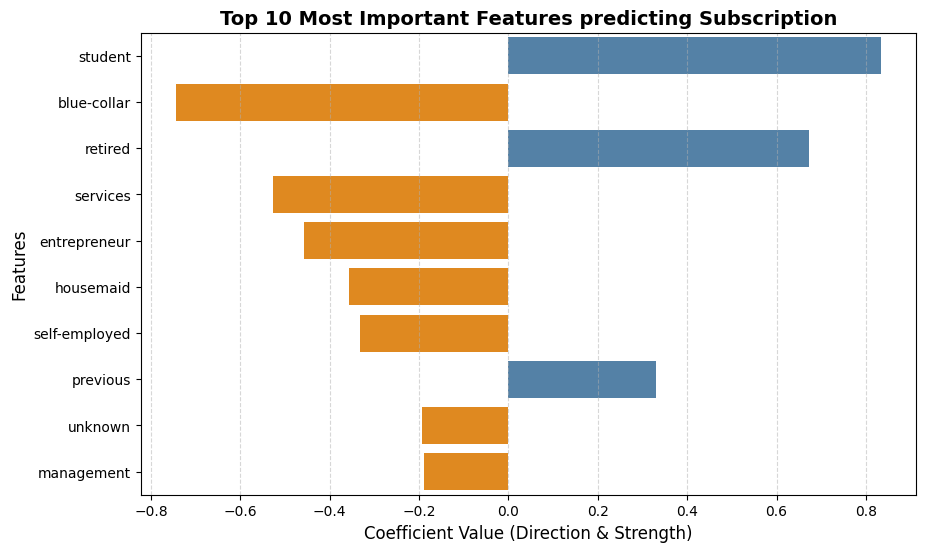

In [16]:
# Feature importance
import numpy as np

# 1. Get the weights (coefficients) from the model
coefficients = model.coef_[0]

# 2. Create a dataframe linking feature names to their weights
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': coefficients
})

# 3. Calculate absolute importance to sort them by overall impact strength
importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False).head(10) # Top 10 features

# 4. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
# Using a conditional color palette: Blue for positive impact, Orange for negative impact
colors = ['#4682B4' if x > 0 else '#FF8C00' for x in importance_df['Importance']]

sns.barplot(data=importance_df, x='Importance', y='Feature', palette=colors)

plt.title('Top 10 Most Important Features predicting Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Direction & Strength)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 5. Display the chart
plt.show()


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.